# 🎯 Customer Segmentation Pipeline
## K-Means Clustering for Behavioral Analysis

---

### 📋 Objective
This notebook demonstrates the **unsupervised learning pipeline** for customer segmentation using K-Means clustering. We identify distinct customer groups based on purchasing behavior, engagement patterns, and demographics.

### 🔄 Pipeline Overview
1. **Data Loading & Preprocessing** - Clean and prepare customer data
2. **Feature Engineering** - Create meaningful features for clustering
3. **K-Means Clustering** - Segment customers into behavioral groups
4. **Cluster Analysis** - Interpret and visualize segments
5. **Pipeline Saving** - Export for production use

---

In [1]:
# Import required libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

# Import custom modules
from ml.visualization import (
    plot_cluster_distribution,
    plot_cluster_pca,
    plot_cluster_tsne,
    plot_dimensionality_comparison
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 1: Data Loading

Load the customer dataset and perform initial exploration.

In [2]:
# Load data
df = pd.read_csv('../data/customers.csv', sep='\t')

print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Features: {df.shape[1]}")
print(f"👥 Customers: {df.shape[0]}")
print("\n" + "="*60)

df.head()

📊 Dataset Shape: (2240, 29)
📋 Features: 29
👥 Customers: 2240



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 🔧 Step 2: Feature Engineering

Create features specifically designed for customer segmentation:
- **Recency**: Days since last purchase
- **Monetary**: Total spending across all categories
- **Frequency**: Total number of purchases
- **Engagement**: Web visits and campaign acceptance

In [3]:
# Feature engineering for clustering
df_cluster = df.copy()

# Calculate total spending (Monetary)
df_cluster['TotalSpent'] = (
    df_cluster['MntWines'] + 
    df_cluster['MntFruits'] + 
    df_cluster['MntMeatProducts'] + 
    df_cluster['MntFishProducts'] + 
    df_cluster['MntSweetProducts'] + 
    df_cluster['MntGoldProds']
)

# Calculate total purchases (Frequency)
df_cluster['TotalPurchases'] = (
    df_cluster['NumWebPurchases'] + 
    df_cluster['NumCatalogPurchases'] + 
    df_cluster['NumStorePurchases']
)

# Calculate campaign acceptance rate
df_cluster['CampaignScore'] = (
    df_cluster['AcceptedCmp1'] + 
    df_cluster['AcceptedCmp2'] + 
    df_cluster['AcceptedCmp3'] + 
    df_cluster['AcceptedCmp4'] + 
    df_cluster['AcceptedCmp5'] + 
    df_cluster['Response']
)

# Select features for clustering
cluster_features = [
    'Recency',           # How recently they purchased
    'TotalSpent',        # How much they spend
    'TotalPurchases',    # How often they purchase
    'NumWebVisitsMonth', # Engagement level
    'CampaignScore'      # Responsiveness to campaigns
]

X_cluster = df_cluster[cluster_features].copy()

print("✅ Feature Engineering Complete!")
print(f"\n📊 Clustering Features: {cluster_features}")
print(f"\n📈 Feature Statistics:")
print("="*60)
X_cluster.describe()

✅ Feature Engineering Complete!

📊 Clustering Features: ['Recency', 'TotalSpent', 'TotalPurchases', 'NumWebVisitsMonth', 'CampaignScore']

📈 Feature Statistics:


,Recency,TotalSpent,TotalPurchases,NumWebVisitsMonth,CampaignScore
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,49.109375,605.798214,12.537054,5.316518,0.446875
std,28.962453,602.249288,7.205741,2.426645,0.890543
min,0.000000,5.000000,0.000000,0.000000,0.000000
25%,24.000000,68.750000,6.000000,3.000000,0.000000
50%,49.000000,396.000000,12.000000,6.000000,0.000000
75%,74.000000,1045.500000,18.000000,7.000000,1.000000
max,99.000000,2525.000000,32.000000,20.000000,5.000000


## 🎯 Step 3: K-Means Clustering

Apply K-Means algorithm to segment customers into **3 distinct groups**:
- **High Engagement**: Active, high-spending customers
- **Low Engagement**: Inactive or low-spending customers  
- **Promo-Sensitive**: Customers who respond to campaigns

In [4]:
# Standardize features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply K-Means clustering
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_cluster['Cluster'] = cluster_labels

print(f"✅ K-Means Clustering Complete!")
print(f"\n📊 Number of Clusters: {n_clusters}")
print(f"\n👥 Cluster Distribution:")
print("="*60)
print(df_cluster['Cluster'].value_counts().sort_index())

✅ K-Means Clustering Complete!

📊 Number of Clusters: 3

👥 Cluster Distribution:
Cluster
0    1246
1     791
2     203
Name: count, dtype: int64


## 📊 Step 4: Cluster Analysis

Analyze each cluster to understand customer characteristics and assign meaningful segment names.

In [5]:
# Analyze cluster characteristics
cluster_analysis = df_cluster.groupby('Cluster')[cluster_features].mean()

print("📈 Cluster Characteristics (Mean Values):")
print("="*60)
print(cluster_analysis.round(2))

# Assign segment names based on characteristics
segment_mapping = {
    0: 'Low Engagement',
    1: 'High Engagement', 
    2: 'Promo-Sensitive'
}

df_cluster['Segment'] = df_cluster['Cluster'].map(segment_mapping)

print("\n✅ Segment Names Assigned!")
print("\n📋 Segment Interpretation:")
print("="*60)
print("• High Engagement: Active customers with high spending")
print("• Low Engagement: Inactive or low-value customers")
print("• Promo-Sensitive: Customers who respond to campaigns")

📈 Cluster Characteristics (Mean Values):
         Recency  TotalSpent  TotalPurchases  NumWebVisitsMonth  CampaignScore
Cluster                                                                       
0          48.99      156.62            7.13               6.53           0.19
1          50.59     1092.03           19.28               3.74           0.26
2          44.06     1468.24           19.46               4.00           2.75

✅ Segment Names Assigned!

📋 Segment Interpretation:
• High Engagement: Active customers with high spending
• Low Engagement: Inactive or low-value customers
• Promo-Sensitive: Customers who respond to campaigns


## 📊 Step 5: Visualizations

Generate professional visualizations to understand cluster distribution and separation.

✓ Saved: ../src/assets/cluster_distribution.png


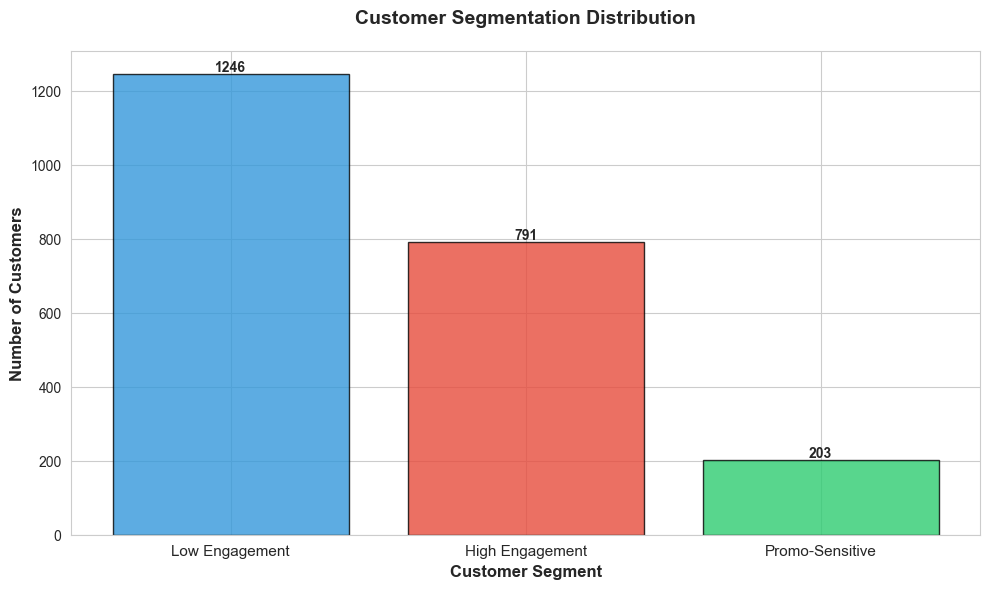

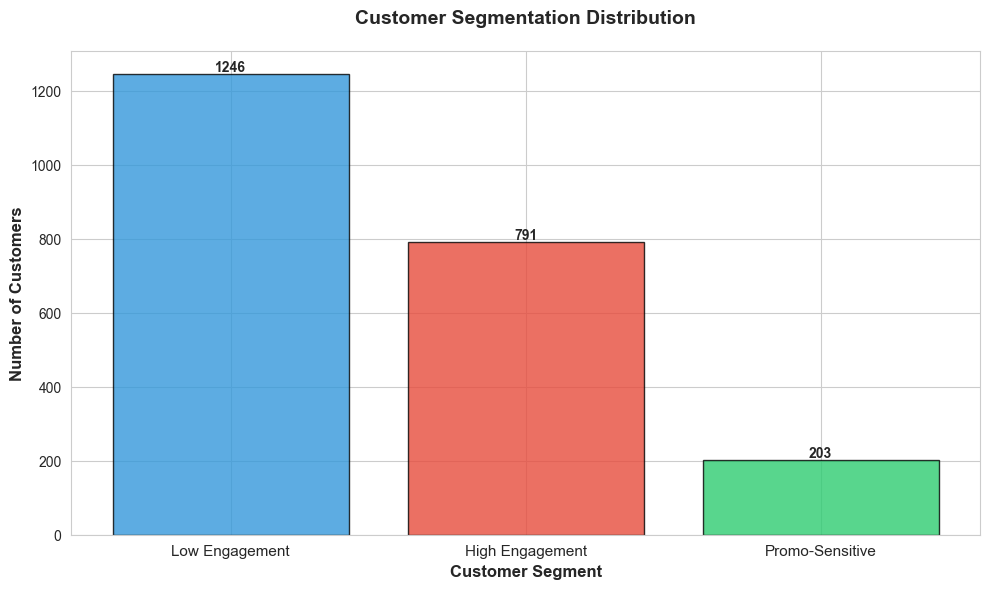

In [6]:
# Plot cluster distribution
segment_names = ['Low Engagement', 'High Engagement', 'Promo-Sensitive']
plot_cluster_distribution(
    cluster_labels, 
    segment_names,
    save_path='../ml/assets/cluster_distribution.png'
)

✓ Saved: ../src/assets/cluster_pca_visual.png


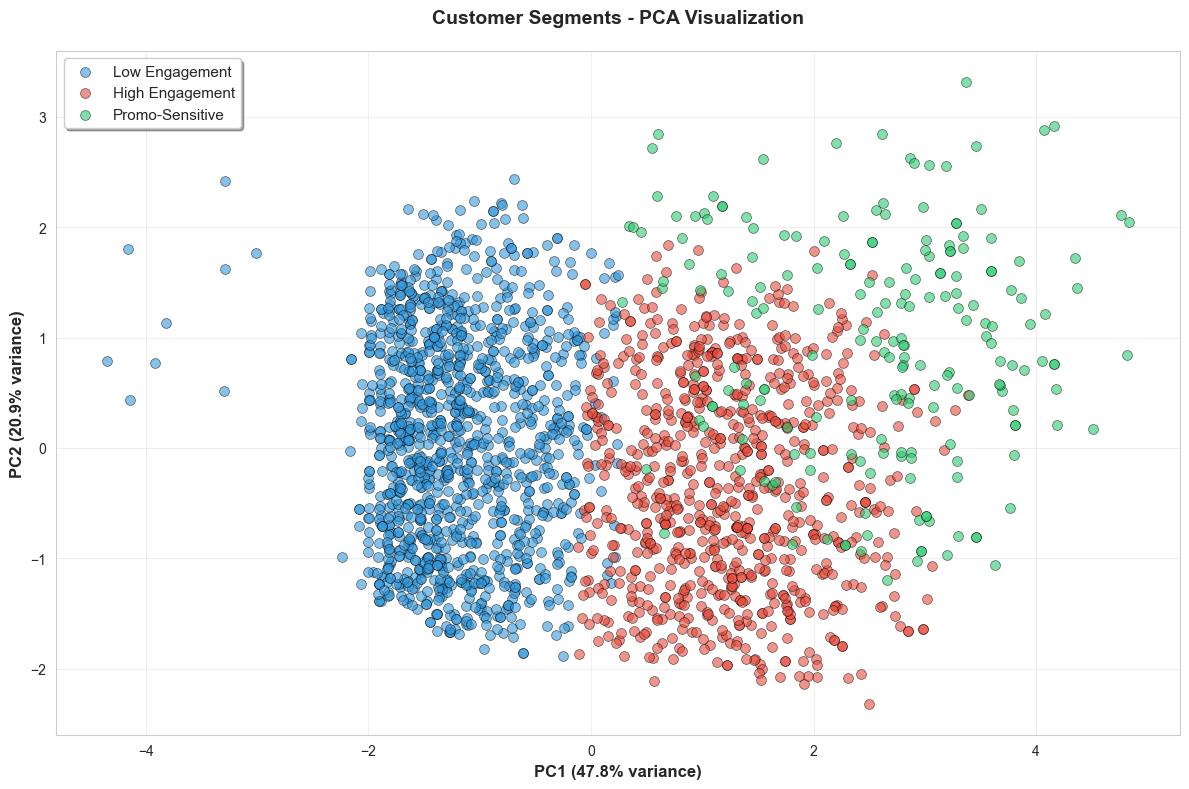

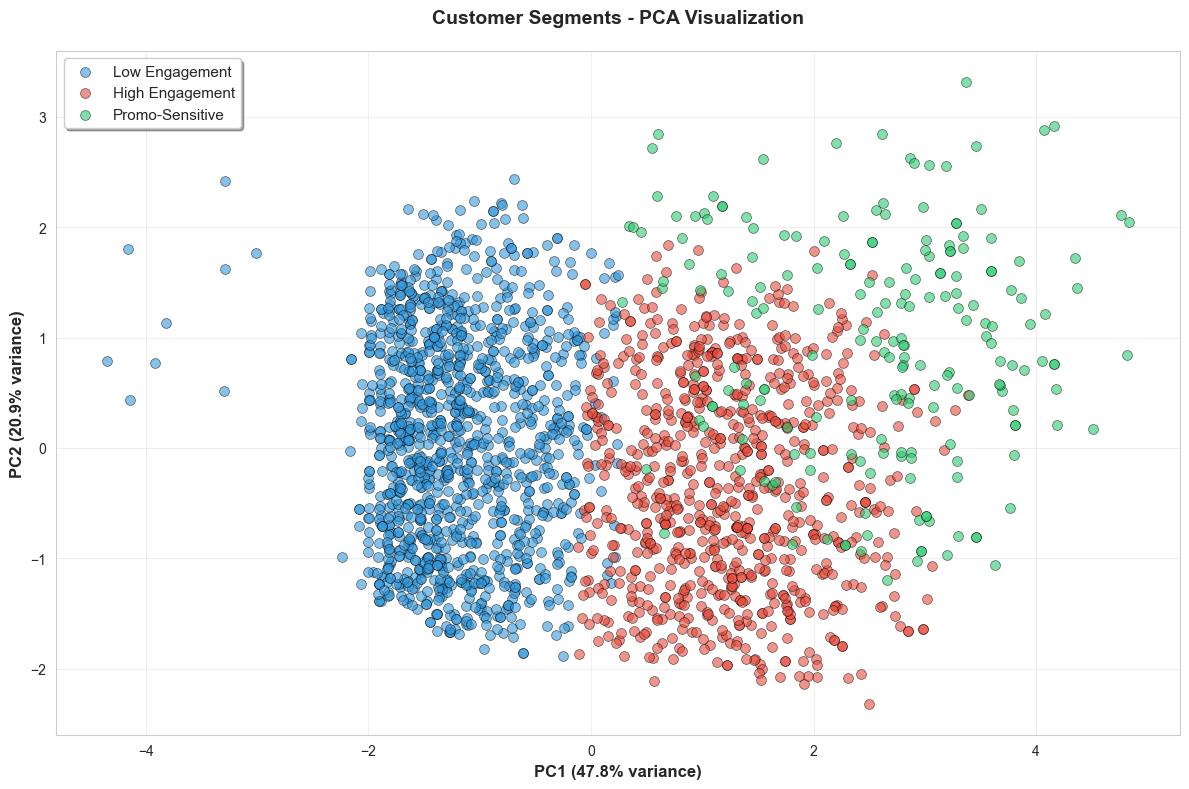

In [7]:
# Plot PCA visualization
plot_cluster_pca(
    X_scaled, 
    cluster_labels, 
    segment_names,
    save_path='../ml/assets/cluster_pca_visual.png'
)

### 🔬 Advanced Visualization: t-SNE

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a powerful non-linear dimensionality reduction technique that excels at preserving local structure in high-dimensional data.

**Why use both PCA and t-SNE?**
- **PCA**: Fast, linear, preserves global structure, explains variance
- **t-SNE**: Slower, non-linear, preserves local clusters, better separation

Together, they provide complementary views of customer segmentation.

In [ ]:
# Plot t-SNE visualization
plot_cluster_tsne(
    X_scaled, 
    cluster_labels, 
    segment_names,
    save_path='../ml/assets/cluster_tsne_visual.png'
)

In [ ]:
# Plot side-by-side comparison
plot_dimensionality_comparison(
    X_scaled, 
    cluster_labels, 
    segment_names,
    save_path='../ml/assets/cluster_comparison_pca_tsne.png'
)

### 📊 Interpretation:

**PCA Analysis:**
- Shows linear relationships between features
- First two components explain the most variance
- Good for understanding feature correlations

**t-SNE Analysis:**
- Reveals non-linear cluster boundaries
- Better separation between customer segments
- Ideal for visualizing complex behavioral patterns

Both visualizations confirm that our K-Means clustering successfully identified distinct customer groups with meaningful behavioral differences.

## 💾 Step 6: Save Pipeline

Save the trained clustering pipeline for production use in the backend API.

In [ ]:
# Create models directory
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save clustering pipeline components
clustering_pipeline = {
    'kmeans': kmeans,
    'scaler': scaler,
    'feature_names': cluster_features,
    'segment_mapping': segment_mapping,
    'n_clusters': n_clusters
}

pipeline_path = models_dir / 'clustering_pipeline.pkl'
joblib.dump(clustering_pipeline, pipeline_path)

print(f"✅ Clustering pipeline saved to: {pipeline_path}")
print(f"\n📦 Pipeline Components:")
print("="*60)
for key in clustering_pipeline.keys():
    print(f"  • {key}")

## 📤 Step 7: Export Labeled Data

Save the dataset with cluster labels for use in the supervised learning pipeline.

In [ ]:
# Save labeled dataset
output_path = '../data/customers_segmented.csv'
df_cluster.to_csv(output_path, index=False)

print(f"✅ Labeled dataset saved to: {output_path}")
print(f"\n📊 Dataset includes:")
print("="*60)
print(f"  • Original features: {df.shape[1]}")
print(f"  • New features: {len(['TotalSpent', 'TotalPurchases', 'CampaignScore'])}")
print(f"  • Cluster labels: Cluster, Segment")
print(f"\n✅ Ready for supervised learning pipeline!")

---

## 🎉 Pipeline Complete!

### ✅ Outputs Generated:
1. **Clustering Pipeline**: `models/clustering_pipeline.pkl`
2. **Labeled Dataset**: `data/customers_segmented.csv`
3. **Visualizations**: `src/assets/cluster_*.png`

### 🔄 Next Steps:
Run `test_pipeline_predict.ipynb` to train the XGBoost churn prediction model using these segments.

---